# Dissolved Oxygen (DO) Gap-Filling Pipeline

This notebook applies a quality-control and gap-filling pipeline to any number of hourly DO time series (e.g. `EF01 - OD.csv`, `EF02 - OD.csv`, `EF03 - OD.csv`, `EF06 - OD.csv`, `EF07 - OD.csv`, `EF08 - OD.csv`).

## What it does
1. **Physical QC** — removes physically impossible values (< 0 or > 14.5 mg/L).
2. **Regime inference** — classifies the DO behaviour (hypoxic, regulated, diel-productive, turbulent, intermediate) and selects detection parameters accordingly.
3. **Constancy detection** — flags extended flat-line periods likely caused by sensor fouling or drift, and marks them as missing.
4. **Hierarchical gap-filling** — fills gaps with the most appropriate method based on gap length:
   - ≤ 6 h → linear time interpolation
   - 7–36 h → centred moving average
   - 37–72 h → STL decomposition reconstruction
   - > 72 h → Prophet seasonal model
5. **Output** — for each station, produces a DataFrame and a CSV containing only the **imputed values** (i.e. timestamps that were missing in the raw series — either originally absent or removed by the constancy check).

## Input format
Each CSV must have at least two columns:
- `Data` — datetime string in `DD/MM/YYYY HH:MM` format
- `Media` — the DO measurement (mg/L)

Separator: `;`  |  Decimal: `,`


## Station Map

## 0 — Configuration

In [1]:
# ─── Station files to process ────────────────────────────────────────────────
# Each entry: (station_label, csv_filename)
STATIONS = [
    ("EF01", "EF01 - OD.csv"),
    ("EF02", "EF02 - OD.csv"),
    ("EF03", "EF03 - OD.csv"),
    ("EF06", "EF06 - OD.csv"),
    ("EF07", "EF07 - OD.csv"),
    ("EF08", "EF08 - OD.csv"),
]

# Date range used for the gap-filling pipeline
START_DATE  = "2015-01-01"
START_DATES = {lbl: START_DATE for lbl, _ in STATIONS}

# Physical plausibility bounds (mg/L)
DO_MIN = 0.0
DO_MAX = 14.5

# Gap-size thresholds (hours) for method selection
T1 = 10   # up to T1  → linear interpolation
T2 = 42   # T1+1 to T2 → moving average
T3 = 72   # T2+1 to T3 → STL  (up to 72 h); above → Prophet
          # > T3        → Prophet

# Output directory (leave as '.' for the same folder as the notebook)
OUTPUT_DIR = "."

## 1 — Imports

In [2]:
import warnings
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from prophet import Prophet

warnings.filterwarnings("ignore")


def _da(obs, pred):
    d_obs, d_pred = np.diff(obs), np.diff(pred)
    mask = d_obs != 0
    if not mask.any():
        return np.nan
    return float(np.mean(np.sign(d_obs[mask]) == np.sign(d_pred[mask])))

def _mda(obs, pred):
    d_obs, d_pred = np.diff(obs), np.diff(pred)
    if len(d_obs) == 0:
        return np.nan
    return float(np.mean(np.sign(d_obs) == np.sign(d_pred)))

def _maed(obs, pred):
    if len(obs) < 2:
        return np.nan
    return float(np.mean(np.abs(np.diff(obs) - np.diff(pred))))

def _ce_trend(obs, pred, eps=1e-9):
    d_obs, d_pred = np.diff(obs), np.diff(pred)
    if len(d_obs) == 0:
        return np.nan
    nz = d_obs[d_obs != 0]
    lim = float(np.percentile(np.abs(nz), 90)) if len(nz) > 0 else 1e-6
    edges = np.array([-np.inf, -lim, lim, np.inf])
    p = np.histogram(d_obs,  bins=edges)[0] / len(d_obs)
    q = np.histogram(d_pred, bins=edges)[0] / len(d_pred)
    q = np.clip(q, eps, 1); q /= q.sum()
    return float(-np.sum(p * np.log(q)))

## 2 — Station Map

Static map of the six CETESB monitoring stations along the Tietê River Basin, suitable for publication.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import geopandas as gpd
import contextily as ctx
from shapely.geometry import Point, LineString, Polygon
import pyproj
import warnings
warnings.filterwarnings("ignore")

# ── Station metadata ──────────────────────────────────────────────────────────
stations_info = {
    "EF01": {
        "lat": -(23+32/60+5/3600+40/3600), "lng": -(46+8/60+5/3600),
        "name": "Mogi das Cruzes",   "water": "Tietê R. (headwaters)",
        "color": "#1a9e8f", "dx": ( 0.022,  0.010), "ha": "left",
    },
    "EF02": {
        "lat": -(23+22/60+56/3600),         "lng": -(47+1/60+48/3600),
        "name": "Rasgão",            "water": "Rasgão Reservoir",
        "color": "#e07b0a", "dx": ( 0.020,  0.012), "ha": "left",
    },
    "EF03": {
        "lat": -(22+57/60+26/3600),         "lng": -(47+49/60+13/3600),
        "name": "Laranjal Paulista", "water": "Tietê R. (middle reach)",
        "color": "#4a90d9", "dx": ( 0.025,  0.010), "ha": "left",
    },
    "EF06": {
        "lat": -(22+42/60+0/3600),          "lng": -(47+42/60+43/3600),
        "name": "Ártemis",           "water": "Piracicaba River",
        "color": "#1aab78", "dx": ( 0.025,  0.010), "ha": "left",
    },
    "EF07": {
        "lat": -(23+46/60+9/3600),          "lng": -(46+31/60+59/3600),
        "name": "Rio Grande",        "water": "Billings Reservoir",
        "color": "#c0392b", "dx": ( 0.025, -0.020), "ha": "left",
    },
    "EF08": {
        "lat": -(23+40/60+18/3600),         "lng": -(46+43/60+36/3600),
        "name": "Guarapiranga",      "water": "Guarapiranga Reservoir",
        "color": "#8e44ad", "dx": (-0.032,  0.012), "ha": "right",
    },
}

# ── River paths ───────────────────────────────────────────────────────────────
tiete_path = [
    (-45.855,-23.530),(-45.960,-23.543),(-46.070,-23.549),
    (-46.135,-23.546),   # ≈ EF01
    (-46.250,-23.545),(-46.380,-23.540),(-46.490,-23.530),
    (-46.580,-23.510),(-46.660,-23.490),(-46.740,-23.470),
    (-46.840,-23.450),(-46.920,-23.420),(-46.980,-23.400),
    (-47.030,-23.382),   # ≈ EF02
    (-47.150,-23.300),(-47.280,-23.150),(-47.420,-23.040),
    (-47.550,-23.020),(-47.670,-22.970),
    (-47.820,-22.957),   # ≈ EF03
    (-47.920,-22.910),(-47.990,-22.850),
]

piracicaba_path = [
    (-47.18,-22.730),(-47.30,-22.722),(-47.45,-22.716),
    (-47.57,-22.713),(-47.65,-22.712),
    (-47.712,-22.700),  # ≈ EF06
    (-47.80,-22.680),(-47.93,-22.650),(-48.02,-22.618),
]

pinheiros_path = [
    (-46.748,-23.508),(-46.735,-23.535),(-46.722,-23.560),
    (-46.712,-23.590),(-46.705,-23.620),(-46.700,-23.650),
    (-46.705,-23.680),(-46.710,-23.710),(-46.718,-23.733),
    (-46.727,-23.748),
]

# ── Reservoir polygons (approximate outlines) ─────────────────────────────────
billings_poly = [
    (-46.280,-23.720),(-46.310,-23.715),(-46.340,-23.718),
    (-46.370,-23.725),(-46.400,-23.735),(-46.420,-23.748),
    (-46.440,-23.762),(-46.460,-23.774),(-46.480,-23.782),
    (-46.510,-23.790),(-46.540,-23.800),(-46.570,-23.808),
    (-46.600,-23.812),(-46.630,-23.810),(-46.655,-23.800),
    (-46.672,-23.785),(-46.668,-23.768),(-46.650,-23.756),
    (-46.628,-23.750),(-46.600,-23.746),(-46.570,-23.742),
    (-46.540,-23.740),(-46.510,-23.742),(-46.485,-23.748),
    (-46.460,-23.755),(-46.440,-23.752),(-46.420,-23.742),
    (-46.400,-23.732),(-46.375,-23.724),(-46.345,-23.718),
    (-46.310,-23.715),(-46.280,-23.720),
]

guarapiranga_poly = [
    (-46.670,-23.630),(-46.695,-23.635),(-46.718,-23.645),
    (-46.730,-23.655),(-46.737,-23.668),(-46.742,-23.682),
    (-46.745,-23.698),(-46.748,-23.715),(-46.745,-23.732),
    (-46.738,-23.748),(-46.725,-23.760),(-46.710,-23.762),
    (-46.698,-23.752),(-46.690,-23.738),(-46.685,-23.720),
    (-46.680,-23.702),(-46.675,-23.685),(-46.668,-23.668),
    (-46.660,-23.652),(-46.655,-23.637),(-46.660,-23.628),
    (-46.670,-23.630),
]

rasgao_poly = [
    (-46.960,-23.406),(-46.985,-23.400),(-47.010,-23.390),
    (-47.030,-23.382),(-47.055,-23.378),(-47.075,-23.374),
    (-47.065,-23.370),(-47.040,-23.368),(-47.015,-23.370),
    (-46.990,-23.375),(-46.965,-23.384),(-46.952,-23.395),
    (-46.952,-23.403),(-46.960,-23.406),
]

# ── Project all geometries to Web Mercator ────────────────────────────────────
fwd = pyproj.Transformer.from_crs("EPSG:4326","EPSG:3857",always_xy=True)

gdf = gpd.GeoDataFrame(
    [{"id":k,"name":v["name"],"color":v["color"],"water":v["water"],"dx":v["dx"],"ha":v["ha"]}
     for k,v in stations_info.items()],
    geometry=[Point(v["lng"],v["lat"]) for v in stations_info.values()],
    crs="EPSG:4326").to_crs("EPSG:3857")

tiete_gdf      = gpd.GeoDataFrame(geometry=[LineString(tiete_path)],      crs="EPSG:4326").to_crs("EPSG:3857")
piracicaba_gdf = gpd.GeoDataFrame(geometry=[LineString(piracicaba_path)],  crs="EPSG:4326").to_crs("EPSG:3857")
pinheiros_gdf  = gpd.GeoDataFrame(geometry=[LineString(pinheiros_path)],   crs="EPSG:4326").to_crs("EPSG:3857")
billings_gdf   = gpd.GeoDataFrame(geometry=[Polygon(billings_poly)],       crs="EPSG:4326").to_crs("EPSG:3857")
guarap_gdf     = gpd.GeoDataFrame(geometry=[Polygon(guarapiranga_poly)],    crs="EPSG:4326").to_crs("EPSG:3857")
rasgao_gdf     = gpd.GeoDataFrame(geometry=[Polygon(rasgao_poly)],          crs="EPSG:4326").to_crs("EPSG:3857")

# ── Map extent ────────────────────────────────────────────────────────────────
all_lngs = [v["lng"] for v in stations_info.values()]
all_lats  = [v["lat"] for v in stations_info.values()]
x_min,y_min = fwd.transform(min(all_lngs)-0.35, min(all_lats)-0.20)
x_max,y_max = fwd.transform(max(all_lngs)+0.65, max(all_lats)+0.22)

# ── Figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13,9), dpi=300)
ax.set_xlim(x_min, x_max); ax.set_ylim(y_min, y_max)

# CartoDB Positron basemap (light, unobtrusive)
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=9, alpha=1.0)

# Reservoir / water body polygons
for poly in [billings_gdf, guarap_gdf, rasgao_gdf]:
    poly.plot(ax=ax, color="#9ecae1", edgecolor="#2171b5", linewidth=1.6, alpha=0.72, zorder=3)

# Pinheiros River (engineered inter-basin transfer, dashed)
pinheiros_gdf.plot(ax=ax, color="#6baed6", linewidth=1.4, alpha=0.65,
                   linestyle=(0,(5,4)), zorder=4)

# Piracicaba River (tributary)
piracicaba_gdf.plot(ax=ax, color="#2196F3", linewidth=2.2, alpha=0.82, zorder=5)

# Tietê River main stem (thickest)
tiete_gdf.plot(ax=ax, color="#08519c", linewidth=3.0, alpha=0.90, zorder=6)

# Flow direction arrows — Tietê
for i in [3, 8, 13, 18]:
    if i+1 < len(tiete_path):
        p1 = gpd.GeoDataFrame(geometry=[Point(tiete_path[i])],   crs="EPSG:4326").to_crs("EPSG:3857")
        p2 = gpd.GeoDataFrame(geometry=[Point(tiete_path[i+1])], crs="EPSG:4326").to_crs("EPSG:3857")
        ax.annotate("", xy=(p2.geometry.x[0],p2.geometry.y[0]),
                    xytext=(p1.geometry.x[0],p1.geometry.y[0]),
                    arrowprops=dict(arrowstyle="-|>",color="#08519c",lw=1.8,mutation_scale=12),zorder=7)

# Flow direction arrow — Piracicaba
p1 = gpd.GeoDataFrame(geometry=[Point(piracicaba_path[5])], crs="EPSG:4326").to_crs("EPSG:3857")
p2 = gpd.GeoDataFrame(geometry=[Point(piracicaba_path[6])], crs="EPSG:4326").to_crs("EPSG:3857")
ax.annotate("", xy=(p2.geometry.x[0],p2.geometry.y[0]),
            xytext=(p1.geometry.x[0],p1.geometry.y[0]),
            arrowprops=dict(arrowstyle="-|>",color="#2196F3",lw=1.5,mutation_scale=11),zorder=7)

# Station markers
for _, row in gdf.iterrows():
    ax.scatter(row.geometry.x, row.geometry.y, s=300,
               color=row["color"], edgecolors="white", linewidths=2.2, zorder=9)

# Station labels (bold ID + name)
for sid, sinfo in stations_info.items():
    row  = gdf[gdf["id"]==sid].iloc[0]
    dlng, dlat = sinfo["dx"]
    xo, yo = fwd.transform(sinfo["lng"]+dlng, sinfo["lat"]+dlat)
    ax.text(xo, yo, f"$\\bf{{{sid}}}$  {sinfo['name']}",
            fontsize=8, ha=sinfo["ha"], va="center", color="#1a1a2e",
            bbox=dict(boxstyle="round,pad=0.28",fc="white",ec="#dddddd",alpha=0.90,lw=0.6),
            zorder=10)

# Water body italic labels
wb_labels = [
    ((-46.50,-23.780), "Billings\nReservoir",       "#08519c", 7.5),
    ((-46.70,-23.705), "Guarapiranga\nReservoir",    "#08519c", 7.5),
    ((-47.01,-23.353), "Rasgão Res.",                "#08519c", 6.5),
    ((-46.66,-23.390), "Tietê River",                "#08519c", 8.5),
    ((-47.60,-22.780), "Piracicaba River",           "#2196F3", 7.5),
    ((-46.72,-23.584), "Pinheiros R.\n(engineered)", "#6baed6", 6.5),
]
for (lng,lat),label,color,fs in wb_labels:
    xo, yo = fwd.transform(lng, lat)
    ax.text(xo, yo, label, fontsize=fs, ha="center", va="center",
            color=color, fontstyle="italic", fontweight="semibold",
            bbox=dict(boxstyle="round,pad=0.20",fc="white",ec="none",alpha=0.70),zorder=8)

# ── Axes dimensions (used by scale bar) ─────────────────────────────────────
ax_w = x_max - x_min; ax_h = y_max - y_min

# ── Scale bar (~50 km) ────────────────────────────────────────────────────────
scale_m = 50_000
sb_x0 = x_min + ax_w*0.040
sb_y0 = y_min + ax_h*0.040
sb_y1 = sb_y0 + ax_h*0.008
ax.fill_between([sb_x0, sb_x0+scale_m/2], [sb_y0]*2, [sb_y1]*2, color="#333", zorder=11)
ax.fill_between([sb_x0+scale_m/2, sb_x0+scale_m], [sb_y0]*2, [sb_y1]*2,
                color="white", edgecolor="#333", zorder=11)
ax.text(sb_x0,            sb_y1+ax_h*0.005, "0",      ha="center",va="bottom",fontsize=6.5,color="#333",zorder=11)
ax.text(sb_x0+scale_m,    sb_y1+ax_h*0.005, "50 km",  ha="center",va="bottom",fontsize=6.5,color="#333",zorder=11)

# ── Legend ────────────────────────────────────────────────────────────────────
handles = [
    mlines.Line2D([],[],color="#08519c",lw=2.8,label="Tietê River"),
    mlines.Line2D([],[],color="#2196F3",lw=2.2,label="Piracicaba River"),
    mlines.Line2D([],[],color="#6baed6",lw=1.4,linestyle=(0,(5,4)),label="Pinheiros R. (engineered)"),
    mpatches.Patch(facecolor="#9ecae1",edgecolor="#2171b5",lw=1.2,label="Reservoir / Water body"),
]
for sid, sinfo in stations_info.items():
    handles.append(mlines.Line2D([],[],marker="o",color="w",
        markerfacecolor=sinfo["color"],markeredgecolor="white",markersize=9,
        label=f"{sid} — {sinfo['name']} ({sinfo['water']})"))

ax.legend(handles=handles, loc="upper right",
          fontsize=7.2, framealpha=0.95, edgecolor="#cccccc",
          title="Water Bodies & Monitoring Stations", title_fontsize=7.8,
          handlelength=1.8, borderpad=0.8)

# ── Axis labels and ticks ─────────────────────────────────────────────────────
lon_ticks = [-48.0,-47.5,-47.0,-46.5,-46.0,-45.5]
lat_ticks = [-24.0,-23.5,-23.0,-22.5]
ax.set_xticks([fwd.transform(lon,-23.0)[0] for lon in lon_ticks])
ax.set_xticklabels([f"{abs(d):.1f}°W" for d in lon_ticks], fontsize=7.5)
ax.set_yticks([fwd.transform(-47.0,lat)[1] for lat in lat_ticks])
ax.set_yticklabels([f"{abs(d):.1f}°S" for d in lat_ticks], fontsize=7.5)
ax.set_xlabel("Longitude", fontsize=9, labelpad=6)
ax.set_ylabel("Latitude",  fontsize=9, labelpad=6)

ax.set_title(
    "CETESB Water Quality Monitoring Stations — Tietê River Basin (São Paulo, Brazil)",
    fontsize=10, fontweight="bold", pad=12,
)

plt.tight_layout()
plt.savefig("station_map.png", dpi=300, bbox_inches="tight")
plt.show()
print("→ Saved: station_map.png")


## 3 — Core functions

### 3.1 Regime inference

In [4]:
def extract_do_metrics(od: pd.Series) -> dict:
    """
    Compute summary statistics that characterise the DO time series.

    Parameters
    ----------
    od : pd.Series
        Hourly DO values (mg/L) with a DatetimeIndex.

    Returns
    -------
    dict with keys: std, amp_dia, acf_24, p_low, diel_strength
    """
    od = od.dropna()

    std = od.std()

    # Median daily amplitude (max − min per day)
    amp_dia = (
        od.resample("D")
          .apply(lambda x: x.max() - x.min() if len(x) > 0 else np.nan)
    ).median()

    # 24-lag autocorrelation (persistence of diel cycle)
    acf_24 = od.autocorr(24)

    # Fraction of time below hypoxic threshold (2 mg/L)
    p_low = (od < 2).mean()

    # Strength of the average diel cycle
    hourly_means = od.groupby(od.index.hour).mean()
    diel_strength = hourly_means.max() - hourly_means.min()

    return {
        "std": std,
        "amp_dia": amp_dia,
        "acf_24": acf_24,
        "p_low": p_low,
        "diel_strength": diel_strength,
    }


def classify_do_regime(metrics: dict) -> str:
    """
    Assign one of five regime labels based on the extracted metrics.

    Regimes
    -------
    impactado_hipoxico    : mostly hypoxic, low variability
    amortecido_regulado   : high autocorrelation, low variance (regulated reach)
    produtivo_diel        : clear diel signal (algal/macrophyte dominated)
    turbulento_cabec      : high amplitude, low persistence (headwater)
    intermediario         : does not fit the above categories
    """
    std  = metrics["std"]
    amp  = metrics["amp_dia"]
    acf  = metrics["acf_24"]
    plow = metrics["p_low"]
    diel = metrics["diel_strength"]

    if plow > 0.5 and amp < 0.5:
        return "impactado_hipoxico"
    if acf > 0.8 and std < 0.4:
        return "amortecido_regulado"
    if diel > 1.0 and amp > 1.0:
        return "produtivo_diel"
    if amp > 2.0 and acf < 0.4:
        return "turbulento_cabec"
    return "intermediario"


def params_for_regime(regime: str) -> dict:
    """
    Return recommended QC and gap-filling parameters for a given regime.

    The returned dict contains:
      janela        : rolling window size for constancy detection
      eps           : maximum allowed range (mg/L) within the window
      std_max       : maximum allowed std (mg/L) within the window
      slope_max     : maximum allowed linear slope magnitude (mg/L per step)
      min_obs       : minimum non-NaN observations required in the window
      max_small_gap : largest gap (h) treated as 'small' for interpolation
    """
    table = {
        "impactado_hipoxico": {
            "janela": "72h", "eps": 0.30, "std_max": 0.15,
            "slope_max": 0.010, "min_obs": 48, "max_small_gap": 12,
        },
        "amortecido_regulado": {
            "janela": "72h", "eps": 0.25, "std_max": 0.12,
            "slope_max": 0.008, "min_obs": 48, "max_small_gap": 8,
        },
        "produtivo_diel": {
            "janela": "48h", "eps": 0.20, "std_max": 0.10,
            "slope_max": 0.006, "min_obs": 36, "max_small_gap": 6,
        },
        "turbulento_cabec": {
            "janela": "24h", "eps": 0.15, "std_max": 0.08,
            "slope_max": 0.005, "min_obs": 24, "max_small_gap": 4,
        },
        "intermediario": {
            "janela": "48h", "eps": 0.25, "std_max": 0.12,
            "slope_max": 0.008, "min_obs": 36, "max_small_gap": 6,
        },
    }
    return table[regime]


def infer_regime_and_params(od: pd.Series):
    """Convenience wrapper: metrics → regime → params."""
    metrics = extract_do_metrics(od)
    regime  = classify_do_regime(metrics)
    params  = params_for_regime(regime)
    return regime, metrics, params

### 3.2 Constancy detector

In [5]:
def detect_constant_do(
    od: pd.Series,
    janela: str  = "48h",
    eps: float   = 0.5,
    std_max: float  = 0.5,
    slope_max: float = 0.1,
    min_obs: int = 24,
) -> pd.Series:
    """
    Flag timestamps where the DO signal appears artificially constant,
    typically caused by sensor fouling, clogging, or drift.

    A window is flagged when ALL three conditions hold simultaneously:
      - range (max − min) < eps
      - standard deviation < std_max
      - absolute linear slope < slope_max

    Parameters
    ----------
    od        : hourly DO series with DatetimeIndex
    janela    : rolling window duration (pandas offset string, e.g. '48h')
    eps       : maximum admissible range within the window (mg/L)
    std_max   : maximum admissible std within the window (mg/L)
    slope_max : maximum admissible |slope| (mg/L per time step)
    min_obs   : minimum number of valid observations required in the window

    Returns
    -------
    pd.Series[bool]  — True where the signal is suspected to be constant.
    """
    od = od.dropna()

    amp = od.rolling(janela, min_periods=min_obs).apply(
        lambda x: x.max() - x.min(), raw=False
    )
    std = od.rolling(janela, min_periods=min_obs).std()

    def _slope(x):
        t = np.arange(len(x))
        return np.polyfit(t, x, 1)[0]

    slp = od.rolling(janela, min_periods=min_obs).apply(_slope, raw=False)

    return (amp < eps) & (std < std_max) & (slp.abs() < slope_max)

### 3.3 Gap-filling methods

In [6]:
def fill_interp(df: pd.DataFrame, target: str = "OD", limit: int = None) -> pd.DataFrame:
    """Time-based linear interpolation (short gaps only)."""
    out = df.copy()
    out["OD_INTERP"] = out[target].interpolate(method="time", limit_area="inside", limit=limit)
    return out


def fill_moving_average(df: pd.DataFrame, target: str = "OD", window: int = 24) -> pd.DataFrame:
    """Fill gaps with a centred rolling mean."""
    out = df.copy()
    out["OD_MA"] = out[target].fillna(
        out[target].rolling(window, min_periods=1, center=True).mean()
    )
    return out


def fill_stl(df: pd.DataFrame, target: str = "OD", period: int = 24) -> pd.DataFrame:
    """
    Fill gaps using STL (Seasonal-Trend decomposition using LOESS).
    The trend + seasonal reconstruction is used to fill missing values.
    """
    out = df.copy()
    ts  = df[target].interpolate(limit_direction="both").ffill().bfill()  # edge NaNs for STL input only
    stl = STL(ts, period=period, robust=True).fit()
    recon = stl.trend + stl.seasonal
    out["OD_STL"] = df[target].fillna(recon)
    return out


def fill_prophet(df: pd.DataFrame, target: str = "OD",
                 cps: float = 0.1, sps: float = 10.0) -> pd.DataFrame:
    """
    Fill gaps with a Prophet seasonal model (hourly + daily + weekly + yearly).
    Fitted only on observed data; predictions are used to fill NaN positions.
    """
    out = df.reset_index().rename(columns={df.index.name: "ds", target: "y"})
    model = Prophet(
        daily_seasonality=True,
        weekly_seasonality=True,
        yearly_seasonality=True,
        changepoint_prior_scale=cps,
        seasonality_prior_scale=sps,
    )
    model.fit(out.dropna(subset=["y"]))
    forecast = model.predict(out[["ds"]])
    out["OD_PROP"] = forecast["yhat"].values
    return out.set_index("ds")


def fill_hierarchical(
    df: pd.DataFrame,
    df_interp:  pd.DataFrame,
    df_rf:      pd.DataFrame,   # kept for API compatibility; not used in default thresholds
    df_ma:      pd.DataFrame,
    df_stl:     pd.DataFrame,
    df_prop:    pd.DataFrame,
    t1: int = 6,
    t2: int = 24,
    t3: int = 120,
) -> pd.DataFrame:
    """
    Combine multiple gap-filling methods in a hierarchy based on gap length.

    Gap length thresholds
    ---------------------
    ≤ t1        → time interpolation  (OD_INTERP)
    t1+1 to t2  → STL reconstruction  (OD_STL)
    t2+1 to t3  → moving average      (OD_MA)
    > t3        → Prophet             (OD_PROP)

    Within each gap, any positions left as NaN by the primary method are
    filled by the next tier down (hierarchical fallback), ensuring no gap
    is left partially empty after this function returns.
    """
    filled = df.copy()
    filled["OD_filled"]      = df["OD"]
    filled["OD_fill_method"] = pd.NA

    is_nan = df["OD"].isna()
    gap_id = (~is_nan).cumsum()
    gap_sizes = is_nan.groupby(gap_id).sum()

    # Fallback chain: ordered from most to least specific
    fallback_chain = [
        ("OD_INTERP", df_interp, "Interp."),
        ("OD_MA",     df_ma,     "MA"),
        ("OD_STL",    df_stl,    "STL"),
        ("OD_PROP",   df_prop,   "Prophet"),
    ]

    for gid, size in gap_sizes.items():
        if size == 0:
            continue
        idx = gap_id[(gap_id == gid) & is_nan].index

        # Select primary method by gap size
        if size <= t1:
            primary = ("OD_INTERP", df_interp, "Interp.")
        elif size <= t2:
            primary = ("OD_STL", df_stl, "STL")
        elif size <= t3:
            primary = ("OD_MA", df_ma, "MA")
        else:
            primary = ("OD_PROP", df_prop, "Prophet")

        col, df_src, label = primary
        filled.loc[idx, "OD_filled"]      = df_src.loc[idx, col]
        filled.loc[idx, "OD_fill_method"] = label

        # Hierarchical fallback: fill any NaN left by the primary method
        still_nan = filled.loc[idx, "OD_filled"].isna()
        if still_nan.any():
            primary_tier = next(i for i, (c, _, _) in enumerate(fallback_chain) if c == col)
            for fb_col, fb_df, fb_label in fallback_chain[primary_tier + 1:]:
                nan_idx = still_nan[still_nan].index
                if nan_idx.empty:
                    break
                fb_vals = fb_df.loc[nan_idx, fb_col]
                filled.loc[nan_idx, "OD_filled"]      = fb_vals
                filled.loc[nan_idx[~fb_vals.isna()], "OD_fill_method"] = fb_label
                still_nan = filled.loc[idx, "OD_filled"].isna()

    return filled

## 3 — Full pipeline for a single station

In [7]:
def trim_sparse_start(
    od: pd.Series,
    min_fill_rate: float = 0.70,
    min_quarters_per_year: int = 3,
) -> pd.Timestamp:
    """Find the earliest quarter-start where:
      (1) the first quarter itself has >= min_fill_rate of non-NaN values, AND
      (2) among the 4 quarters of that year, at least min_quarters_per_year are complete.
    Advances one quarter at a time; returns the stable start timestamp.
    If no such window exists, returns the first timestamp unchanged.
    """
    first_ts = od.index[0]
    last_ts  = od.index[-1]

    first_quarter_start = first_ts.to_period('Q').to_timestamp()
    quarter_starts = pd.date_range(start=first_quarter_start, end=last_ts, freq='QS')

    for qs in quarter_starts:
        complete_quarters = 0
        first_quarter_ok  = False
        for j in range(4):
            q_start = qs + pd.DateOffset(months=3 * j)
            q_end   = qs + pd.DateOffset(months=3 * (j + 1))

            if q_start >= last_ts:
                break

            q_start_eff = max(q_start, first_ts)
            q_end_eff   = min(q_end, last_ts + pd.Timedelta(hours=1))
            expected = int((q_end_eff - q_start_eff).total_seconds() / 3600)
            if expected == 0:
                continue

            mask   = (od.index >= q_start) & (od.index < q_end)
            filled = int(od[mask].notna().sum())

            if filled / expected >= min_fill_rate:
                complete_quarters += 1
                if j == 0:
                    first_quarter_ok = True

        if first_quarter_ok and complete_quarters >= min_quarters_per_year:
            return qs

    return first_ts


def run_do_pipeline(
    csv_path: str,
    station_label: str,
    start_date: str = START_DATE,
    do_min: float   = DO_MIN,
    do_max: float   = DO_MAX,
    t1: int = T1, t2: int = T2, t3: int = T3,
    plot: bool = True,
    save_csv: bool = True,
    output_dir: str = OUTPUT_DIR,
) -> pd.DataFrame:
    """
    End-to-end QC + gap-filling pipeline for a single DO station.

    Steps
    -----
    1. Load CSV and restrict to >= start_date.
    2. Physical QC: set values outside [do_min, do_max] to NaN.
    3. Infer DO regime and select constancy-detection parameters.
    4. Flag extended flat-line periods as NaN.
    5. Apply hierarchical gap-filling.
    6. Clip filled values to [0, do_max].
    7. (Optionally) plot and export only the imputed timestamps.

    Returns
    -------
    pd.DataFrame with columns:
      - OD          : quality-controlled series (NaN at removed/missing positions)
      - OD_filled   : fully gap-filled series
      - imputed     : bool — True where a value was imputed (gap or constancy flag)
      - flag_source : 'originally_missing' | 'constancy_flag' | 'observed'
    """
    print(f"\n{'='*60}")
    print(f" Station: {station_label}  |  File: {os.path.basename(csv_path)}")
    print(f"{'='*60}")

    # ── 1. Load ────────────────────────────────────────────────────
    raw = pd.read_csv(csv_path, sep=";", decimal=",")
    raw["Data"] = pd.to_datetime(raw["Data"], format="%d/%m/%Y %H:%M")
    raw = (
        raw[raw["Data"] >= start_date]
        .set_index("Data")[["Media"]]
        .rename(columns={"Media": "OD"})
        .sort_index()
    )
    raw["OD"] = pd.to_numeric(raw["OD"], errors="coerce")
    print(f"  Records loaded   : {len(raw):,}")
    print(f"  Missing in raw   : {raw['OD'].isna().sum():,}  "
          f"({raw['OD'].isna().mean()*100:.1f}%)")

    # ── 1b. Trim sparse start ──────────────────────────────────────
    new_start = trim_sparse_start(raw["OD"])
    if new_start > raw.index[0]:
        n_dropped = (raw.index < new_start).sum()
        print(f"  Sparse start trimmed: {raw.index[0].date()} → {new_start.date()} "
              f"({n_dropped:,} h dropped, <70% fill in first year – <3 complete quarters)")
        raw = raw.loc[new_start:]

    # ── 2. Physical QC ────────────────────────────────────────────
    df = raw.copy()
    originally_missing = df["OD"].isna().copy()
    df.loc[(df["OD"] < do_min) | (df["OD"] > do_max), "OD"] = np.nan
    print(f"  After physical QC: {df['OD'].isna().sum():,} NaN")

    # ── 3. Regime inference ───────────────────────────────────────
    regime, metrics, params = infer_regime_and_params(df["OD"])
    print(f"  Inferred regime  : {regime}")

    # ── 4. Constancy detection ────────────────────────────────────
    det_params = {
        k: v for k, v in params.items()
        if k in ["janela", "eps", "std_max", "slope_max", "min_obs"]
    }

    raw_flag = (
        detect_constant_do(df["OD"], **det_params)
        .reindex(df.index, fill_value=False)
    )
    # Require the flag to persist for ≥ 80% of a 48-h window to avoid
    # false positives during naturally calm periods.
    constancy_flag = (
        raw_flag.rolling("48h", min_periods=36).mean() > 0.8
    )
    df.loc[constancy_flag, "OD"] = np.nan
    pct_flagged = constancy_flag.mean() * 100
    print(f"  Constancy-flagged: {pct_flagged:.1f}%")

    # Track imputation source for every row
    flag_source = pd.Series("observed", index=df.index)
    flag_source[originally_missing] = "originally_missing"
    flag_source[constancy_flag & ~originally_missing] = "constancy_flag"

    # ── 5. Hierarchical gap-filling ───────────────────────────────
    print("  Running gap-filling methods...")
    df_interp = fill_interp(df, limit=t1)
    df_ma     = fill_moving_average(df)
    df_stl    = fill_stl(df)
    df_prop   = fill_prophet(df)

    result = fill_hierarchical(
        df, df_interp, df_interp,   # rf placeholder = interp
        df_ma, df_stl, df_prop,
        t1=t1, t2=t2, t3=t3,
    )

    # ── 5b. Single re-apply if NaN remain after all models ───────
    if result["OD_filled"].isna().any():
        still_nan_mask = result["OD_filled"].isna()
        n_before = still_nan_mask.sum()
        print(f"  {n_before} points still missing after all models — re-applying pipeline once...")
        df_refill = result[["OD_filled"]].rename(columns={"OD_filled": "OD"})
        df_i2 = fill_interp(df_refill, limit=t1)
        df_m2 = fill_moving_average(df_refill)
        df_s2 = fill_stl(df_refill)
        df_p2 = fill_prophet(df_refill)
        result2 = fill_hierarchical(
            df_refill, df_i2, df_i2, df_m2, df_s2, df_p2,
            t1=t1, t2=t2, t3=t3,
        )
        result.loc[still_nan_mask, "OD_filled"]      = result2.loc[still_nan_mask, "OD_filled"]
        result.loc[still_nan_mask, "OD_fill_method"] = result2.loc[still_nan_mask, "OD_fill_method"]
        n_after = result["OD_filled"].isna().sum()
        print(f"  Re-apply recovered {n_before - n_after}, remaining {n_after}.")

    # ── 6. Clip ───────────────────────────────────────────────────
    result["OD_filled"] = result["OD_filled"].clip(lower=0)

    # ── 7. Annotate ───────────────────────────────────────────────
    result["imputed"]     = df["OD"].isna()
    result["flag_source"] = flag_source

    n_imputed = result["imputed"].sum()
    print(f"  Total imputed    : {n_imputed:,}  "
          f"({n_imputed/len(result)*100:.1f}%)")

    # ── 8. Plot ───────────────────────────────────────────────────
    if plot:
        _plot_imputed(result, station_label, output_dir)

    # ── 9. Export CSV — only imputed rows ─────────────────────────
    if save_csv:
        out_df = (
            result.loc[result["imputed"], ["OD_filled", "flag_source"]]
            .rename(columns={"OD_filled": "DO_imputed_mgL"})
        )
        csv_out = os.path.join(output_dir, f"{station_label}_DO_imputed.csv")
        out_df.to_csv(csv_out, sep=";", decimal=",")
        print(f"  Saved → {csv_out}")

    return result


def _plot_imputed(result: pd.DataFrame, station_label: str, output_dir: str) -> None:
    """Plot the observed DO series with imputed values highlighted by source."""
    fig, ax = plt.subplots(figsize=(14, 4))

    # Observed series
    ax.plot(
        result.index, result["OD"],
        color="steelblue", linewidth=0.7, alpha=0.7, label="Observed DO",
    )

    # Originally missing — filled values
    mask_orig = result["flag_source"] == "originally_missing"
    ax.scatter(
        result.index[mask_orig], result.loc[mask_orig, "OD_filled"],
        color="orange", s=8, zorder=3, label="Imputed (originally missing)",
    )

    # Constancy-flagged — filled values
    mask_const = result["flag_source"] == "constancy_flag"
    ax.scatter(
        result.index[mask_const], result.loc[mask_const, "OD_filled"],
        color="crimson", s=8, zorder=3, label="Imputed (constancy flag)",
    )

    ax.set_title(f"{station_label} — Dissolved Oxygen: observed + imputed values")
    ax.set_xlabel("Date")
    ax.set_ylabel("DO (mg/L)")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    plt.tight_layout()

    fig_path = os.path.join(output_dir, f"{station_label}_DO_imputed.png")
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Plot saved → {fig_path}")

## 3b — DTW Validation of `trim_sparse_start`

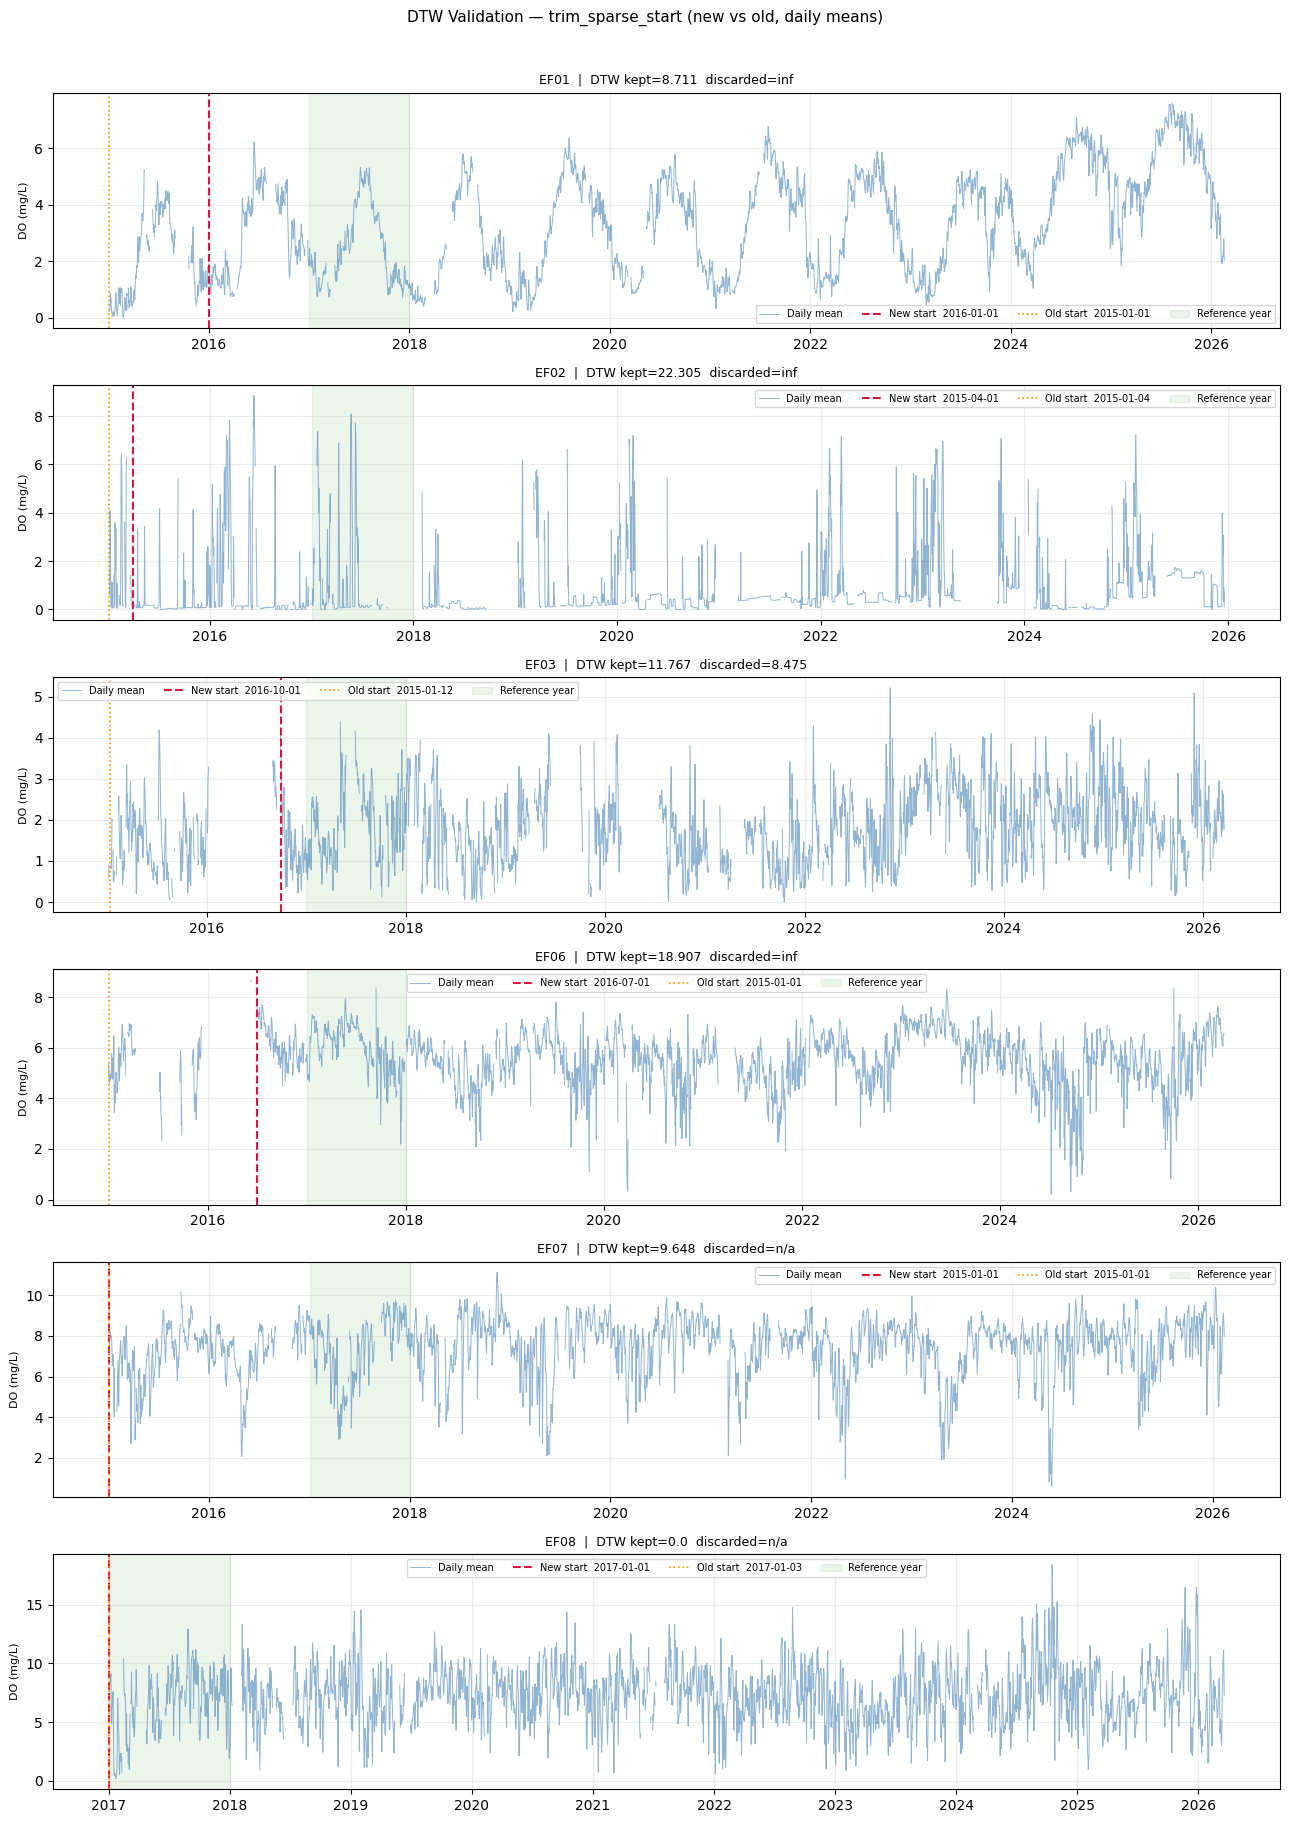


DTW Validation Summary
          old_start   new_start  DTW kept DTW discarded
Station                                                
EF01     2015-01-01  2016-01-01     8.711           inf
EF02     2015-01-04  2015-04-01    22.305           inf
EF03     2015-01-12  2016-10-01    11.767         8.475
EF06     2015-01-01  2016-07-01    18.907           inf
EF07     2015-01-01  2015-01-01     9.648           n/a
EF08     2017-01-03  2017-01-01     0.000           n/a

Interpretation: DTW discarded >> DTW kept → trimming is justified.


In [8]:
# ── DTW Validation of trim_sparse_start ──────────────────────────────────────
# Strategy
# --------
# For each station we compare three segments (daily means) using DTW:
#   (A) discarded : period before new_start  (if any)
#   (B) kept_1yr  : first year after new_start
#   (C) reference : a stable year from the middle of the series (year 3)
#
# Expected result:
#   DTW(discarded, reference)  >>  DTW(kept_1yr, reference)
# → confirms what was removed was anomalous and what was kept is representative.
#
# Old trim uses the original rolling-window logic (window=200, min_filled=120)
# so we can also compare how the two approaches differ.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── Minimal DTW with Sakoe-Chiba band (no external dependency) ───────────────
def _dtw_distance(a: np.ndarray, b: np.ndarray, window_frac: float = 0.10) -> float:
    """DTW distance with Sakoe-Chiba band (window = window_frac * len)."""
    a, b = np.asarray(a, dtype=float), np.asarray(b, dtype=float)
    n, m = len(a), len(b)
    w = max(1, int(max(n, m) * window_frac))
    D = np.full((n + 1, m + 1), np.inf)
    D[0, 0] = 0.0
    for i in range(1, n + 1):
        j_lo = max(1, i - w)
        j_hi = min(m, i + w)
        for j in range(j_lo, j_hi + 1):
            cost = (a[i - 1] - b[j - 1]) ** 2
            D[i, j] = cost + min(D[i - 1, j], D[i, j - 1], D[i - 1, j - 1])
    return float(np.sqrt(D[n, m]))

# ── Old trim logic (rolling-window) ──────────────────────────────────────────
def _old_trim_sparse_start(od: pd.Series, window: int = 200, min_filled: int = 120):
    obs = od.notna().astype(int)
    rc  = obs.rolling(window=window, min_periods=window).sum().shift(-window + 1)
    valid = rc[rc >= min_filled]
    return od.index[0] if valid.empty else valid.index[0]

# ── Load raw series (same logic as run_do_pipeline step 1) ───────────────────
def _load_raw(filename: str, start_date: str = START_DATE) -> pd.Series:
    raw = pd.read_csv(filename, sep=";", decimal=",")
    raw["Data"] = pd.to_datetime(raw["Data"], format="%d/%m/%Y %H:%M")
    raw = (
        raw[raw["Data"] >= start_date]
        .set_index("Data")[["Media"]]
        .rename(columns={"Media": "OD"})
        .sort_index()
    )
    raw["OD"] = pd.to_numeric(raw["OD"], errors="coerce")
    return raw["OD"]

# ── Helper: get daily means for a slice, drop NaN, return as ndarray ─────────
def _daily(od: pd.Series, start, end) -> np.ndarray:
    seg = od.loc[start:end].resample("D").mean().dropna()
    return seg.values

# ── Main validation loop ──────────────────────────────────────────────────────
rows = []
fig, axes = plt.subplots(len(STATIONS), 1, figsize=(13, 3 * len(STATIONS)), sharex=False)
if len(STATIONS) == 1:
    axes = [axes]

for ax, (label, filename) in zip(axes, STATIONS):
    od = _load_raw(filename)
    first_ts = od.index[0]
    last_ts  = od.index[-1]

    old_start = _old_trim_sparse_start(od)
    new_start = trim_sparse_start(od)

    # Reference: year 3 (index offset of 2 years from first_ts)
    ref_s = first_ts + pd.DateOffset(years=2)
    ref_e = ref_s   + pd.DateOffset(years=1)
    ref   = _daily(od, ref_s, ref_e)

    # Kept first year (new trim)
    kept  = _daily(od, new_start, new_start + pd.DateOffset(years=1))

    # Discarded segment (between original start and new_start)
    if new_start > first_ts:
        disc = _daily(od, first_ts, new_start)
    else:
        disc = np.array([])

    n_ref = len(ref)

    dtw_kept = _dtw_distance(kept[:n_ref], ref[:n_ref]) if len(kept) >= 10 else np.nan
    dtw_disc = _dtw_distance(disc[:n_ref], ref[:n_ref]) if len(disc) >= 10 else np.nan

    rows.append({
        "Station"     : label,
        "old_start"   : old_start.date(),
        "new_start"   : new_start.date(),
        "DTW kept"    : round(dtw_kept, 3) if not np.isnan(dtw_kept) else "—",
        "DTW discarded": round(dtw_disc, 3) if not np.isnan(dtw_disc) else "n/a",
    })

    # ── Plot daily means ──────────────────────────────────────────────────────
    daily = od.resample("D").mean()
    ax.plot(daily.index, daily.values, color="steelblue", lw=0.7, alpha=0.6, label="Daily mean")
    ax.axvline(new_start, color="crimson",   lw=1.5, ls="--", label=f"New start  {new_start.date()}")
    ax.axvline(old_start, color="darkorange", lw=1.2, ls=":",  label=f"Old start  {old_start.date()}")
    ax.axvspan(ref_s, ref_e, alpha=0.08, color="green", label="Reference year")
    title = f"{label}  |  DTW kept={rows[-1]['DTW kept']}  discarded={rows[-1]['DTW discarded']}"
    ax.set_title(title, fontsize=9)
    ax.legend(fontsize=7, ncol=4)
    ax.set_ylabel("DO (mg/L)", fontsize=8)
    ax.grid(alpha=0.25)

plt.suptitle("DTW Validation — trim_sparse_start (new vs old, daily means)", fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
df_val = pd.DataFrame(rows).set_index("Station")
print("\nDTW Validation Summary")
print("=" * 60)
print(df_val.to_string())
print("\nInterpretation: DTW discarded >> DTW kept → trimming is justified.")


## 4 — Run pipeline for all stations


 Station: EF01  |  File: EF01 - OD.csv
  Records loaded   : 97,565
  Missing in raw   : 7,539  (7.7%)
  Sparse start trimmed: 2015-01-01 → 2016-01-01 (8,760 h dropped, <70% fill in first year – <3 complete quarters)
  After physical QC: 5,300 NaN
  Inferred regime  : intermediario
  Constancy-flagged: 1.4%
  Running gap-filling methods...


13:52:33 - cmdstanpy - INFO - Chain [1] start processing
13:53:41 - cmdstanpy - INFO - Chain [1] done processing


  2 points still missing after all models — re-applying pipeline once...


13:54:00 - cmdstanpy - INFO - Chain [1] start processing
13:55:25 - cmdstanpy - INFO - Chain [1] done processing


  Re-apply recovered 0, remaining 2.
  Total imputed    : 6,497  (7.3%)


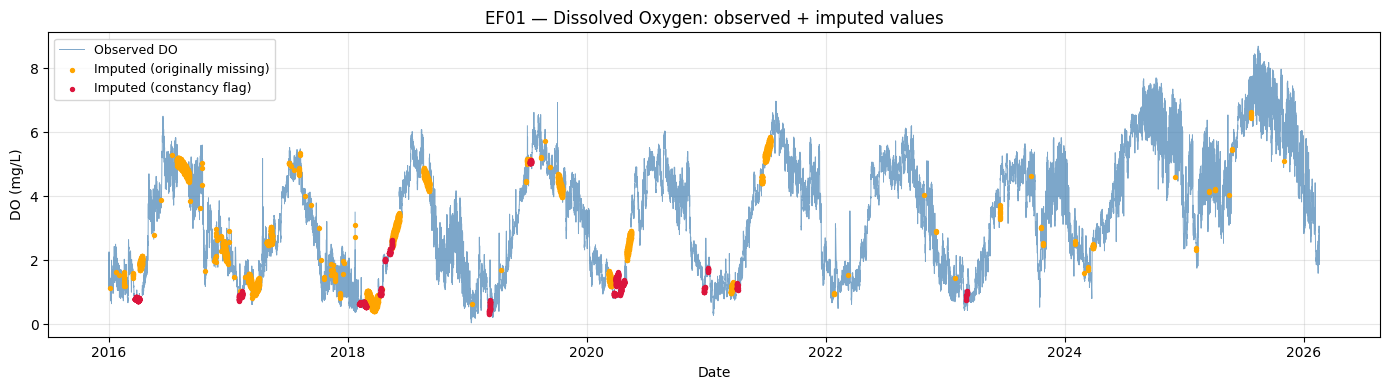

  Plot saved → ./EF01_DO_imputed.png
  Saved → ./EF01_DO_imputed.csv

 Station: EF02  |  File: EF02 - OD.csv
  Records loaded   : 96,112
  Missing in raw   : 21,536  (22.4%)
  Sparse start trimmed: 2015-01-01 → 2015-04-01 (2,160 h dropped, <70% fill in first year – <3 complete quarters)
  After physical QC: 20,731 NaN
  Inferred regime  : impactado_hipoxico
  Constancy-flagged: 44.2%
  Running gap-filling methods...


13:55:57 - cmdstanpy - INFO - Chain [1] start processing
13:56:18 - cmdstanpy - INFO - Chain [1] done processing


  4 points still missing after all models — re-applying pipeline once...


13:56:39 - cmdstanpy - INFO - Chain [1] start processing
13:57:36 - cmdstanpy - INFO - Chain [1] done processing


  Re-apply recovered 4, remaining 0.
  Total imputed    : 61,596  (65.6%)


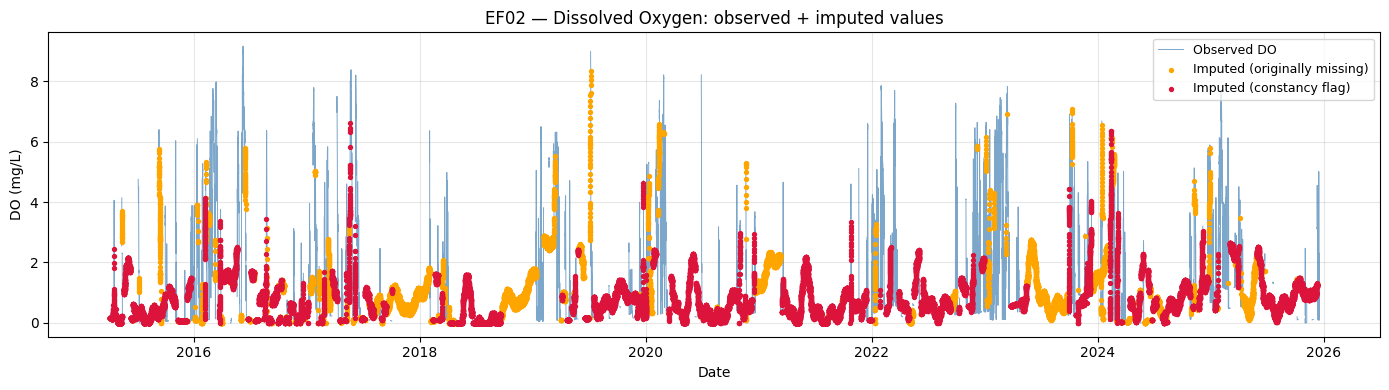

  Plot saved → ./EF02_DO_imputed.png
  Saved → ./EF02_DO_imputed.csv

 Station: EF03  |  File: EF03 - OD.csv
  Records loaded   : 98,291
  Missing in raw   : 25,151  (25.6%)
  Sparse start trimmed: 2015-01-01 → 2016-10-01 (15,336 h dropped, <70% fill in first year – <3 complete quarters)
  After physical QC: 16,881 NaN
  Inferred regime  : intermediario
  Constancy-flagged: 0.4%
  Running gap-filling methods...


13:58:13 - cmdstanpy - INFO - Chain [1] start processing
13:59:00 - cmdstanpy - INFO - Chain [1] done processing


  1 points still missing after all models — re-applying pipeline once...


13:59:22 - cmdstanpy - INFO - Chain [1] start processing
14:00:18 - cmdstanpy - INFO - Chain [1] done processing


  Re-apply recovered 1, remaining 0.
  Total imputed    : 17,228  (20.8%)


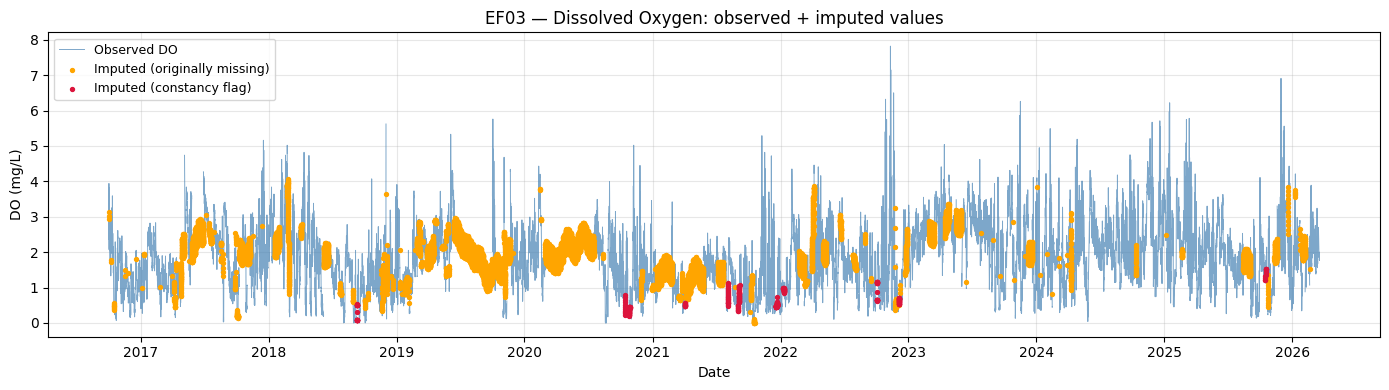

  Plot saved → ./EF03_DO_imputed.png
  Saved → ./EF03_DO_imputed.csv

 Station: EF06  |  File: EF06 - OD.csv
  Records loaded   : 98,743
  Missing in raw   : 15,881  (16.1%)
  Sparse start trimmed: 2015-01-01 → 2016-07-01 (13,128 h dropped, <70% fill in first year – <3 complete quarters)
  After physical QC: 6,197 NaN
  Inferred regime  : produtivo_diel
  Constancy-flagged: 0.0%
  Running gap-filling methods...


14:00:55 - cmdstanpy - INFO - Chain [1] start processing
14:01:40 - cmdstanpy - INFO - Chain [1] done processing


  Total imputed    : 6,197  (7.2%)


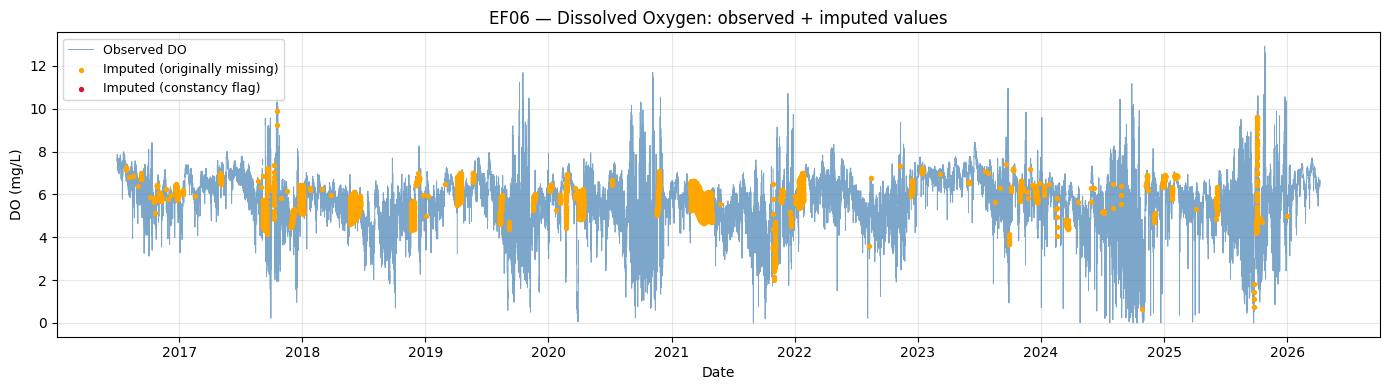

  Plot saved → ./EF06_DO_imputed.png
  Saved → ./EF06_DO_imputed.csv

 Station: EF07  |  File: EF07 - OD.csv
  Records loaded   : 97,456
  Missing in raw   : 5,859  (6.0%)
  After physical QC: 5,859 NaN
  Inferred regime  : intermediario
  Constancy-flagged: 0.0%
  Running gap-filling methods...


14:02:23 - cmdstanpy - INFO - Chain [1] start processing
14:03:40 - cmdstanpy - INFO - Chain [1] done processing


  1 points still missing after all models — re-applying pipeline once...


14:04:04 - cmdstanpy - INFO - Chain [1] start processing
14:04:59 - cmdstanpy - INFO - Chain [1] done processing


  Re-apply recovered 1, remaining 0.
  Total imputed    : 5,859  (6.0%)


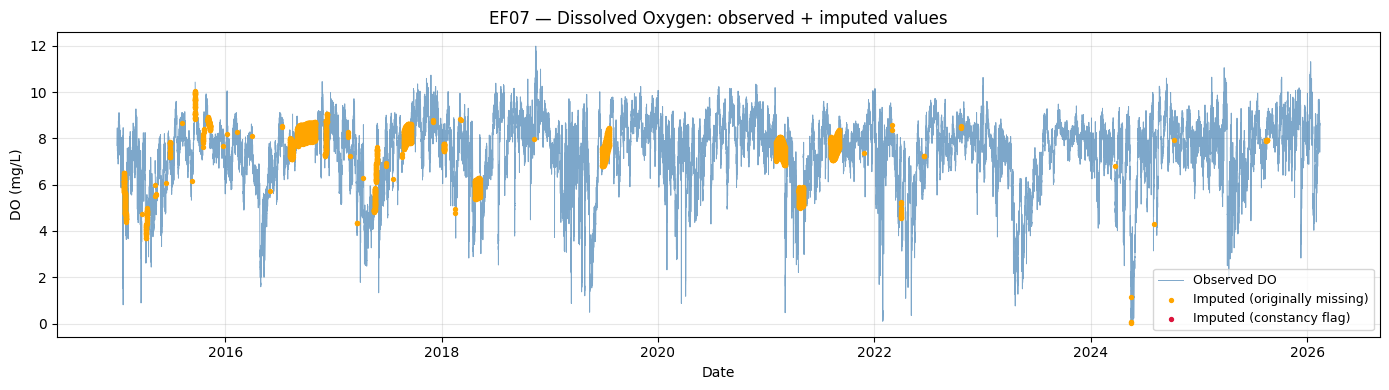

  Plot saved → ./EF07_DO_imputed.png
  Saved → ./EF07_DO_imputed.csv

 Station: EF08  |  File: EF08 - OD.csv
  Records loaded   : 98,315
  Missing in raw   : 23,727  (24.1%)
  Sparse start trimmed: 2015-01-01 → 2017-01-01 (17,544 h dropped, <70% fill in first year – <3 complete quarters)
  After physical QC: 6,983 NaN
  Inferred regime  : produtivo_diel
  Constancy-flagged: 0.0%
  Running gap-filling methods...


14:05:35 - cmdstanpy - INFO - Chain [1] start processing
14:06:27 - cmdstanpy - INFO - Chain [1] done processing


  1 points still missing after all models — re-applying pipeline once...


14:06:46 - cmdstanpy - INFO - Chain [1] start processing
14:07:45 - cmdstanpy - INFO - Chain [1] done processing


  Re-apply recovered 0, remaining 1.
  Total imputed    : 6,983  (8.6%)


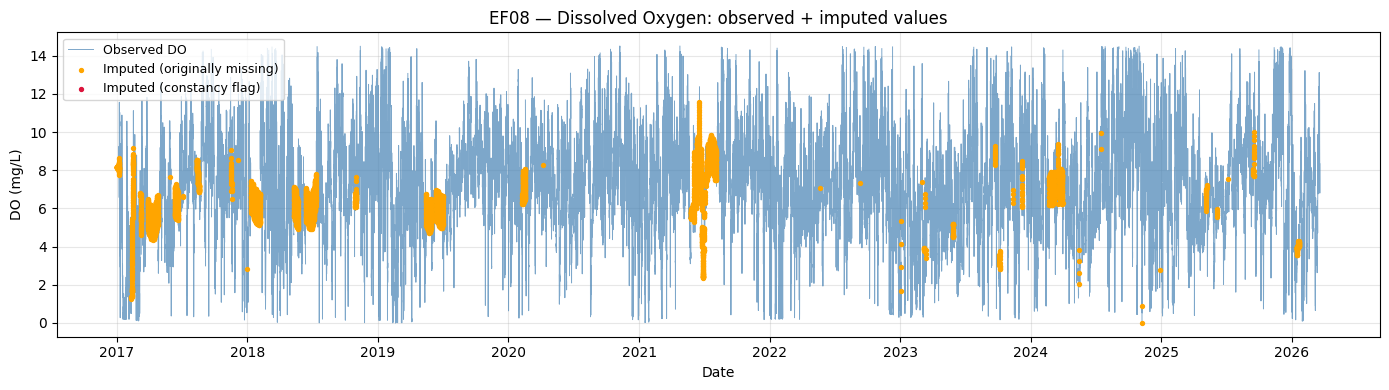

  Plot saved → ./EF08_DO_imputed.png
  Saved → ./EF08_DO_imputed.csv


In [9]:
results = {}   # station_label → processed DataFrame

for label, filename in STATIONS:
    results[label] = run_do_pipeline(
        csv_path      = filename,
        station_label = label,
        start_date    = START_DATES[label],
        do_min        = DO_MIN,
        do_max        = DO_MAX,
        t1 = T1, t2 = T2, t3 = T3,
        plot     = True,
        save_csv = True,
        output_dir = OUTPUT_DIR,
    )

## 5 — Summary table

In [10]:
FILL_METHODS = ["Interp.", "MA", "STL", "Prophet"]

rows = []
for label, df in results.items():
    n_total   = len(df)
    n_orig    = (df["flag_source"] == "originally_missing").sum()
    n_const   = (df["flag_source"] == "constancy_flag").sum()
    n_imputed = df["imputed"].sum()

    method_counts = (
        df.loc[df["imputed"], "OD_fill_method"]
        .value_counts()
        .reindex(FILL_METHODS, fill_value=0)
    ) if "OD_fill_method" in df.columns else pd.Series(0, index=FILL_METHODS)

    row = {
        "Station"               : label,
        "Total records"         : n_total,
        "Originally missing"    : n_orig,
        "Originally missing (%)": round(n_orig  / n_total * 100, 2),
        "Constancy-flagged"     : n_const,
        "Constancy-flagged (%)": round(n_const / n_total * 100, 2),
        "Total imputed"         : n_imputed,
        "Total imputed (%)"     : round(n_imputed / n_total * 100, 2),
    }
    for m in FILL_METHODS:
        row[f"Filled by {m}"]      = int(method_counts[m])
        row[f"Filled by {m} (%)"]  = round(method_counts[m] / n_total * 100, 2)

    rows.append(row)

summary = pd.DataFrame(rows).set_index("Station")
display(summary)


,Total records,Originally missing,Originally missing (%),Constancy-flagged,Constancy-flagged (%),Total imputed,Total imputed (%),Filled by Interp.,Filled by Interp. (%),Filled by MA,Filled by MA (%),Filled by STL,Filled by STL (%),Filled by Prophet,Filled by Prophet (%)
Station,,,,,,,,,,,,,,,
EF01,88805,5300,5.97,1197,1.35,6497,7.32,140,0.16,189,0.21,1241,1.40,4927,5.55
EF02,93952,20729,22.06,40865,43.50,61596,65.56,76,0.08,442,0.47,9099,9.68,51979,55.33
EF03,82955,16865,20.33,347,0.42,17228,20.77,138,0.17,438,0.53,2315,2.79,14337,17.28
EF06,85615,6197,7.24,0,0.00,6197,7.24,135,0.16,203,0.24,2507,2.93,3352,3.92
EF07,97456,5859,6.01,0,0.00,5859,6.01,64,0.07,69,0.07,770,0.79,4956,5.09
EF08,80771,6183,7.65,0,0.00,6983,8.65,339,0.42,713,0.88,1330,1.65,4601,5.70


### 5c — Gap count by duration category (Short / Medium / Long)

In [ ]:
# ── Gap count by duration category ───────────────────────────────────────────
# Short  : gap length ≤ T1        (≤ 10 h)  — filled by Interp.
# Medium : T1 < gap length ≤ T3   (11–72 h) — filled by MA or STL (grouped)
# Long   : gap length > T3        (> 72 h)  — filled by Prophet

def count_gap_events(is_gap: pd.Series, t1: int, t3: int):
    """Count consecutive runs of True in is_gap, categorised by run length."""
    runs   = (is_gap != is_gap.shift()).cumsum()
    in_gap = is_gap[is_gap]
    if in_gap.empty:
        return 0, 0, 0
    lengths = in_gap.groupby(runs[is_gap]).size()
    short   = int((lengths <= t1).sum())
    medium  = int(((lengths > t1) & (lengths <= t3)).sum())
    long_   = int((lengths > t3).sum())
    return short, medium, long_

gap_rows = []
for label, df in results.items():
    is_gap = df["imputed"].astype(bool)
    short, medium, long_ = count_gap_events(is_gap, T1, T3)
    total = short + medium + long_
    gap_rows.append({
        "Station"                       : label,
        f"Short (\u226410 h) [n]"      : short,
        f"Short (\u226410 h) [%]"      : round(short  / total * 100, 1) if total else 0.0,
        f"Medium (11\u201372 h) [n]"   : medium,
        f"Medium (11\u201372 h) [%]"   : round(medium / total * 100, 1) if total else 0.0,
        f"Long (>72 h) [n]"             : long_,
        f"Long (>72 h) [%]"             : round(long_  / total * 100, 1) if total else 0.0,
        "Total gaps [n]"                : total,
    })

gap_summary = pd.DataFrame(gap_rows).set_index("Station")
gap_summary.loc["Total"] = gap_summary.sum()
# Recompute % for total row
for cat in ["Short (\u226410 h)", "Medium (11\u201372 h)", "Long (>72 h)"]:
    tot = gap_summary.loc["Total", "Total gaps [n]"]
    gap_summary.loc["Total", f"{cat} [%]"] = (
        round(gap_summary.loc["Total", f"{cat} [n]"] / tot * 100, 1) if tot else 0.0
    )

print(f"Gap thresholds: short \u2264{T1} h | medium {T1+1}\u2013{T3} h | long >{T3} h")
print()
display(gap_summary)


### 5d — Combined plot: all stations with imputation markers

In [ ]:
# ── Combined 6-station plot with imputation markers ───────────────────────────
station_list = [lbl for lbl, _ in STATIONS]
ncols, nrows = 2, 3

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(18, nrows * 4),
    sharex=False, sharey=False,
)
axes_flat = axes.flatten()

for ax, label in zip(axes_flat, station_list):
    df = results[label]

    # Observed series (raw, before imputation)
    ax.plot(
        df.index, df["OD"],
        color="steelblue", lw=0.7, alpha=0.75, label="Observed DO",
    )

    # Imputed — originally missing
    mask_orig = df["flag_source"] == "originally_missing"
    if mask_orig.any():
        ax.scatter(
            df.index[mask_orig], df.loc[mask_orig, "OD_filled"],
            color="orange", s=5, zorder=3, label="Imputed (missing)",
        )

    # Imputed — constancy-flagged
    mask_const = df["flag_source"] == "constancy_flag"
    if mask_const.any():
        ax.scatter(
            df.index[mask_const], df.loc[mask_const, "OD_filled"],
            color="crimson", s=5, zorder=3, label="Imputed (flatline)",
        )

    ax.set_title(label, fontsize=10, fontweight="bold")
    ax.set_ylabel("DO (mg/L)", fontsize=8)
    ax.tick_params(axis="x", labelsize=7, labelrotation=20)
    ax.tick_params(axis="y", labelsize=7)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=7, markerscale=2)

# Hide any unused axes (if stations < nrows*ncols)
for ax in axes_flat[len(station_list):]:
    ax.set_visible(False)

fig.suptitle(
    "Dissolved Oxygen — Observed series with imputed values (all stations)",
    fontsize=12, fontweight="bold", y=1.01,
)
plt.tight_layout()

out_path = os.path.join(OUTPUT_DIR, "all_stations_DO_imputed.png")
fig.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)
print(f"\u2192 Saved: {out_path}")


## 5b — Baseline I & II: construction, comparison and CSV export

Both baselines are derived from the **QC-cleaned** series
(`results[label]["OD"]` — after physical bounds + constancy detection,
before hierarchical filling) so that all three approaches start from
the same input.

| | **Baseline I** | **Baseline II** | **Hierarchical Filling** |
|---|---|---|---|
| **Método** | ffill → bfill | Interpolação linear + ffill/bfill nas bordas | QC + Interp ≤10 h → MA ≤42 h → STL ≤72 h → Prophet >72 h |
| **Tendência local** | Não (propaga último valor) | Sim (interpola entre vizinhos) | Sim (cada método capta diferentes escalas) |
| **Lacunas longas** | Preenche (mesmo valor) | Preenche (extrapolação linear) | Cobre até >72 h via Prophet |
| **QC / constancy** | Não | Não | Sim |
| **Uso aqui** | Benchmark mínimo | Benchmark linear | Método proposto |


In [ ]:
# ─── Baseline I (ffill/bfill) and Baseline II (linear interp) ────────────────
# Applied to the QC-cleaned OD column so all three approaches are comparable.

import os
import pandas as pd
import numpy as np

baselines_I  = {}
baselines_II = {}

print(f"{'Station':<8}  {'B-I NaN':>10}  {'B-II NaN':>10}  {'Pipeline NaN':>12}")
print("-" * 48)

for label, df_res in results.items():
    od_clean = df_res["OD"].copy()   # QC-cleaned; NaN at gaps + constancy flags

    # Baseline I: forward-fill then back-fill
    b1 = od_clean.ffill().bfill()
    baselines_I[label] = b1

    # Baseline II: linear interpolation between neighbours, edges via ffill/bfill
    b2 = od_clean.interpolate(method="time").ffill().bfill()
    baselines_II[label] = b2

    n1  = b1.isna().sum()
    n2  = b2.isna().sum()
    nok = df_res["OD_filled"].isna().sum()
    print(f"{label:<8}  {n1:>10,}  {n2:>10,}  {nok:>12,}")

    # ── Save Baseline I CSV ───────────────────────────────────────────────────
    df_b1 = pd.DataFrame({
        "Data"          : b1.index,
        "DO_original_mgL": od_clean.values,
        "DO_filled_mgL"  : b1.values,
        "flag_source"    : df_res["flag_source"].values,
    })
    path_b1 = os.path.join(OUTPUT_DIR, f"{label}_DO_baseline_I.csv")
    df_b1.to_csv(path_b1, sep=";", decimal=",", index=False)

    # ── Save Baseline II CSV ──────────────────────────────────────────────────
    df_b2 = pd.DataFrame({
        "Data"          : b2.index,
        "DO_original_mgL": od_clean.values,
        "DO_filled_mgL"  : b2.values,
        "flag_source"    : df_res["flag_source"].values,
    })
    path_b2 = os.path.join(OUTPUT_DIR, f"{label}_DO_baseline_II.csv")
    df_b2.to_csv(path_b2, sep=";", decimal=",", index=False)

    # ── Save complete-series CSV (full QC + hierarchical fill) ────────────────
    df_cs = pd.DataFrame({
        "Data"          : df_res.index,
        "DO_original_mgL": df_res["OD"].values,
        "DO_filled_mgL"  : df_res["OD_filled"].values,
        "imputed"        : df_res["imputed"].values,
        "flag_source"    : df_res["flag_source"].values,
    })
    path_cs = os.path.join(OUTPUT_DIR, f"{label}_DO_complete_series.csv")
    df_cs.to_csv(path_cs, sep=";", decimal=",", index=False)

print()
print("CSV files saved:")
for label, _ in results.items():
    for suffix in ["baseline_I", "baseline_II", "complete_series"]:
        print(f"  {label}_DO_{suffix}.csv")

# ─── Comparison table: mean absolute difference vs pipeline output ────────────
rows_cmp = []
for label, df_res in results.items():
    pipe_filled = df_res["OD_filled"]
    b1_filled   = baselines_I[label]
    b2_filled   = baselines_II[label]

    # Evaluate only at positions that were imputed by the pipeline
    mask = df_res["imputed"]
    obs  = pipe_filled[mask]
    b1v  = b1_filled[mask]
    b2v  = b2_filled[mask]

    def _mae(a, b):
        diff = (a - b).dropna()
        return diff.abs().mean() if len(diff) else np.nan

    rows_cmp.append({
        "Station"               : label,
        "Imputed pts"           : int(mask.sum()),
        "MAE B-I vs Pipeline"  : round(_mae(b1v, obs), 4),
        "MAE B-II vs Pipeline" : round(_mae(b2v, obs), 4),
        "MAE B-I vs B-II"      : round(_mae(b1v, b2v), 4),
    })

cmp_df = pd.DataFrame(rows_cmp).set_index("Station")
print()
print("Mean Absolute Error between fill strategies (at imputed positions):")
display(cmp_df)


## 6 — DTW Final Validation (100 Random Holdouts)

**Strategy:** 100 synthetic gaps with random sizes are drawn uniformly from the original observed series across all stations. Each gap is filled by every method; DTW distance against the held-out ground truth measures reconstruction quality.
Prophet is run only for gaps > T3 (its operative range in the hierarchical selector). STL and Interp/MA run on a local context window for speed.

In [14]:
# =============================================================================
# Section 6 — DTW Final Validation: 100 Random Holdouts
# =============================================================================
# 100 synthetic gaps with uniformly random sizes are sampled from the original
# observed data across all 6 stations.
#
# For each holdout:
#   - A contiguous observed block is located and its centre is masked.
#   - Every imputation method fills the masked segment.
#   - DTW distance is computed between the filled and the true values.
#
# Gap-size range : [T1 // 2 , T3 * 4]  (covers all method territories)
# Prophet        : run only for gaps > T3  (its operative range)
# STL / MA / Interp: run on a local context window (±CTX hours) for speed
# =============================================================================

import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from scipy.stats import ks_2samp

warnings.filterwarnings("ignore")
random.seed(42)
np.random.seed(42)

# ── Configuration ─────────────────────────────────────────────────────────────
N_SAMPLES   = 100                  # total holdout samples
GAP_MIN     = max(1, T1 // 2)     # minimum gap size (hours)
GAP_MAX     = T3 * 4              # maximum gap size (hours)
CTX         = max(96, T3 * 2)     # local context radius for Interp/MA/STL
BUFFER      = max(48, T1 * 4)     # min observed hours on each side of the gap
ALL_METHODS = ["Baseline I", "Baseline II", "Hierarchical"]

# Gap-size bins for stratified reporting
BINS   = [0, T1, T2, T3, GAP_MAX + 1]
LABELS = [f"Short (≤{T1}h)", f"Medium ({T1+1}–{T2}h)",
          f"Long ({T2+1}–{T3}h)", f"Very long (>{T3}h)"]

METHOD_COLORS = {
    "Baseline I"  : "#aaaaaa",
    "Baseline II" : "#f4a261",
    "Hierarchical": "#264653",
}

# ── DTW (Sakoe-Chiba band, no external dependency) ────────────────────────────
def _dtw(a: np.ndarray, b: np.ndarray, w_frac: float = 0.15) -> float:
    a, b = np.asarray(a, float), np.asarray(b, float)
    n, m = len(a), len(b)
    w = max(1, int(max(n, m) * w_frac))
    D = np.full((n + 1, m + 1), np.inf)
    D[0, 0] = 0.0
    for i in range(1, n + 1):
        for j in range(max(1, i - w), min(m, i + w) + 1):
            cost = (a[i-1] - b[j-1]) ** 2
            D[i, j] = cost + min(D[i-1, j], D[i, j-1], D[i-1, j-1])
    return float(np.sqrt(D[n, m]))

# ── Find all valid holdout start positions ────────────────────────────────────
def _valid_starts(od: pd.Series, min_len: int):
    obs = (~od.isna()).values
    n, count = len(obs), 0
    fwd = np.zeros(n, int)
    for i in range(n - 1, -1, -1):
        count = count + 1 if obs[i] else 0
        fwd[i] = count
    return [i for i in range(n) if fwd[i] >= min_len]

# ── Load raw series for each station ─────────────────────────────────────────
raw_series = {}
for label, filename in STATIONS:
    raw = pd.read_csv(filename, sep=";", decimal=",")
    raw["Data"] = pd.to_datetime(raw["Data"], format="%d/%m/%Y %H:%M")
    raw = (raw[raw["Data"] >= START_DATE]
           .set_index("Data")[["Media"]]
           .rename(columns={"Media": "OD"})
           .sort_index())
    raw["OD"] = pd.to_numeric(raw["OD"], errors="coerce")
    raw_series[label] = raw["OD"]

# ── Sample 100 (station, gap_size, position) tuples ──────────────────────────
sample_pool = []
for label, od in raw_series.items():
    for gap_size in np.random.randint(GAP_MIN, GAP_MAX + 1, size=N_SAMPLES * 3):
        gap_size = int(gap_size)
        min_block = gap_size + 2 * BUFFER
        starts = _valid_starts(od, min_block)
        if starts:
            s = random.choice(starts)
            sample_pool.append((label, gap_size, s))

random.shuffle(sample_pool)
samples = sample_pool[:N_SAMPLES]
print(f"Collected {len(samples)} holdout samples  "
      f"(gap range: {min(g for _,g,_ in samples)}–{max(g for _,g,_ in samples)} h)")

# ── Evaluation loop ───────────────────────────────────────────────────────────
dtw_rows = []
n_done = 0

for label, gap_size, s in samples:
    od   = raw_series[label]
    idxs = od.index

    gap_idx   = idxs[s + BUFFER : s + BUFFER + gap_size]
    true_vals = od[gap_idx].values.astype(float)
    if np.isnan(true_vals).any():
        continue

    # Local window for Interp / MA / STL
    lo     = max(0, s - CTX)
    hi     = min(len(od), s + 2 * BUFFER + gap_size + CTX)
    od_win = od.iloc[lo:hi].copy()
    od_win[gap_idx] = np.nan
    df_win = pd.DataFrame({"OD": od_win})

    run_prophet = gap_size > T3

    try:
        df_i = fill_interp(df_win, limit=T1)
        df_a = fill_moving_average(df_win)
        df_s = fill_stl(df_win)

        if run_prophet:
            od_full = od.copy()
            od_full[gap_idx] = np.nan
            df_p_full = fill_prophet(pd.DataFrame({"OD": od_full}))
            df_p = df_p_full.loc[od_win.index]
        else:
            df_p = df_s.copy()
            df_p["OD_PROP"] = df_s["OD_STL"]

        df_h = fill_hierarchical(df_win, df_i, df_i, df_a, df_s, df_p,
                                 t1=T1, t2=T2, t3=T3)
    except Exception as e:
        print(f"  [{label} gap={gap_size}h] error: {e}")
        continue

    # Baseline: ffill/bfill on raw masked window — no leakage
    candidates = {
        "Baseline I"  : od_win.ffill().bfill().loc[gap_idx].values.astype(float),
        "Baseline II" : od_win.interpolate(method="time").ffill().bfill().loc[gap_idx].values.astype(float),
        "Hierarchical": df_h.loc[gap_idx, "OD_filled"].values.astype(float),
    }

    for method, pred in candidates.items():
        ok = ~np.isnan(pred) & ~np.isnan(true_vals)
        if ok.sum() < 2:
            continue
        t, p = true_vals[ok], pred[ok]
        ks_stat, ks_p = ks_2samp(t, p)
        dtw_rows.append({
            "Station"  : label,
            "gap_size" : gap_size,
            "gap_bin"  : pd.cut([gap_size], bins=BINS, labels=LABELS)[0],
            "Method"   : method,
            "DTW"      : _dtw(t, p),
            "Bias"     : float(np.mean(p - t)),
            "KS_stat"  : float(ks_stat),
            "KS_pval"  : float(ks_p),
            "DA"       : _da(t, p),
            "MDA"      : _mda(t, p),
            "MAED"     : _maed(t, p),
            "CETrend"  : _ce_trend(t, p),
        })

    n_done += 1
    if n_done % 10 == 0:
        print(f"  {n_done}/{len(samples)} done...", flush=True)

print(f"\nCompleted {n_done} holdouts → {len(dtw_rows)} method-sample pairs.")

# ── Results ────────────────────────────────────────────────────────────────────
df_dtw = pd.DataFrame(dtw_rows)
methods_present = [m for m in ALL_METHODS if m in df_dtw["Method"].unique()]

METRICS = ["DTW", "Bias", "KS_stat", "DA", "MDA", "MAED", "CETrend"]

# Overall summary table: mean ± std per method
grp = df_dtw.groupby("Method")
rows_summary = []
for method in methods_present:
    sub = grp.get_group(method)
    entry = {"Method": method, "N": len(sub)}
    for col in METRICS:
        entry[f"{col} mean"] = round(sub[col].mean(), 4)
        entry[f"{col} std"]  = round(sub[col].std(),  4)
    entry["KS p<0.05 (%)"] = round((sub["KS_pval"] < 0.05).mean() * 100, 1)
    rows_summary.append(entry)

df_summary = pd.DataFrame(rows_summary).set_index("Method")

print("\n" + "=" * 90)
print("FINAL VALIDATION SUMMARY  —  100 random holdouts  (lower DTW/|Bias|/KS/MAED/CETrend = better; higher DA/MDA = better)")
print("=" * 90)
print(df_summary.to_string())

# Binned table: mean per metric × method × gap category
for metric in METRICS:
    binned = (
        df_dtw.groupby(["gap_bin", "Method"])[metric]
        .mean().round(4)
        .unstack("Method")
        .reindex(LABELS)
        [[m for m in methods_present if m in df_dtw["Method"].unique()]]
    )
    print(f"\n{metric} by gap category (mean):")
    print(binned.to_string())

# ── Figure: 3-panel overview ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1 — DTW mean ± std
ax = axes[0]
means = df_summary["DTW mean"].values
stds  = df_summary["DTW std"].values
bars  = ax.bar(methods_present, means,
               color=[METHOD_COLORS[m] for m in methods_present],
               edgecolor="white", linewidth=0.6)
ax.errorbar(range(len(methods_present)), means, yerr=stds,
            fmt="none", ecolor="black", elinewidth=1.2, capsize=4)
for bar, m, s in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + s + 0.002,
            f"{m:.3f}", ha="center", va="bottom", fontsize=8)
ax.axhline(0, color="black", linewidth=0.5)
ax.set_ylabel("DTW distance (lower = better)")
ax.set_title("DTW — mean ± 1 std")
ax.grid(axis="y", alpha=0.3)

# Panel 2 — Mean Bias ± std (centred on 0)
ax = axes[1]
means_b = df_summary["Bias mean"].values
stds_b  = df_summary["Bias std"].values
colors_b = [METHOD_COLORS[m] for m in methods_present]
bars_b = ax.bar(methods_present, means_b, color=colors_b,
                edgecolor="white", linewidth=0.6)
ax.errorbar(range(len(methods_present)), means_b, yerr=stds_b,
            fmt="none", ecolor="black", elinewidth=1.2, capsize=4)
for bar, m in zip(bars_b, means_b):
    offset = 0.001 if m >= 0 else -0.001
    va = "bottom" if m >= 0 else "top"
    ax.text(bar.get_x() + bar.get_width()/2,
            m + offset, f"{m:+.4f}", ha="center", va=va, fontsize=8)
ax.axhline(0, color="black", linewidth=1.0, linestyle="--")
ax.set_ylabel("Mean Bias  pred − true  (mg/L)")
ax.set_title("Mean Bias — closer to 0 = better")
ax.grid(axis="y", alpha=0.3)

# Panel 3 — KS statistic mean + % rejected (p<0.05)
ax = axes[2]
ks_means = df_summary["KS_stat mean"].values
pct_rej  = df_summary["KS p<0.05 (%)"].values
bars_k = ax.bar(methods_present, ks_means,
                color=[METHOD_COLORS[m] for m in methods_present],
                edgecolor="white", linewidth=0.6)
for bar, k, p in zip(bars_k, ks_means, pct_rej):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.002,
            f"{k:.3f}\n({p:.0f}%)", ha="center", va="bottom", fontsize=7.5)
ax.set_ylabel("KS statistic (lower = better)")
ax.set_title("KS statistic — mean\n(% in parentheses = p<0.05 rejections)")
ax.grid(axis="y", alpha=0.3)

plt.suptitle(
    f"Final Validation  |  N={n_done} holdouts  |  "
    f"gap range {GAP_MIN}–{GAP_MAX} h  |  6 stations",
    fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

# ── Scatter: DTW vs gap size ──────────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(11, 4))
for method in methods_present:
    sub = df_dtw[df_dtw["Method"] == method].sort_values("gap_size")
    ax2.scatter(sub["gap_size"], sub["DTW"],
                color=METHOD_COLORS[method], alpha=0.4, s=18, label=method)
    if len(sub) >= 5:
        roll = (sub.set_index("gap_size")["DTW"]
                .rolling(window=max(3, len(sub)//8), center=True, min_periods=1).mean())
        ax2.plot(roll.index, roll.values,
                 color=METHOD_COLORS[method], linewidth=2.0)
ax2.set_xlabel("Gap size (hours)")
ax2.set_ylabel("DTW distance")
ax2.set_title("DTW vs Gap Size — scatter + rolling mean")
ax2.legend(title="Method", fontsize=8)
ax2.grid(alpha=0.25)
plt.tight_layout()
plt.show()


KeyboardInterrupt: 

## 7 — Time Series Cross-Validation (tsCV)

**Expanding-window tsCV** that respects temporal order:
- Starts with a minimum training window of 1 year; advances by 1 quarter per fold.
- Each fold tests three representative gap sizes (Short / Medium / Long) placed at the end of the training window with a small right-context buffer.
- Methods are evaluated on held-out ground truth using DTW, Mean Bias, and KS statistic.
- Fold-level results are plotted over time to detect temporal degradation.

In [ ]:
# =============================================================================
# Section 7 — Time Series Cross-Validation (tsCV)
# =============================================================================
# Expanding-window strategy — temporal order is preserved:
#
#   |<── training window ──────────────────>|← gap →|← ctx →|
#   fold 1:  [start .. fold_end_1]
#   fold 2:  [start .. fold_end_2]   (fold_end_2 = fold_end_1 + STEP)
#   ...
#
# For each fold × gap size:
#   1. Mask the last GAP_SIZE hours before fold_end (with CTX hours of
#      right-context left observed so MA/Interp have both-side data).
#   2. Run all methods on the full training window up to fold_end.
#   3. Evaluate reconstruction quality (DTW, Bias, KS).
#
# Prophet is excluded — it would need a full refit per fold (~30 s each).
# =============================================================================

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import ks_2samp

warnings.filterwarnings("ignore")

# ── tsCV configuration ────────────────────────────────────────────────────────
INITIAL_WINDOW = 365 * 24      # minimum training hours before first fold
STEP           = 91  * 24      # fold advance (≈ 1 quarter)
CTX_RIGHT      = 48            # observed hours kept to the right of the gap
TSCV_METHODS   = ["Baseline I", "Baseline II", "Hierarchical"]

# One representative gap size per method tier
TSCV_GAP_SIZES = {
    f"Short ({T1}h)"  : T1,
    f"Medium ({T2}h)" : T2,
    f"Long ({T3}h)"   : T3,
}

# ── DTW (reuse same implementation) ──────────────────────────────────────────
def _dtw_ts(a, b, w_frac=0.15):
    a, b = np.asarray(a, float), np.asarray(b, float)
    n, m = len(a), len(b)
    w = max(1, int(max(n, m) * w_frac))
    D = np.full((n + 1, m + 1), np.inf)
    D[0, 0] = 0.0
    for i in range(1, n + 1):
        for j in range(max(1, i - w), min(m, i + w) + 1):
            cost = (a[i-1] - b[j-1]) ** 2
            D[i, j] = cost + min(D[i-1, j], D[i, j-1], D[i-1, j-1])
    return float(np.sqrt(D[n, m]))

# ── Load raw series (self-contained — also available if Section 6 ran first) ──
if "raw_series" not in dir():
    raw_series = {}
    for label, filename in STATIONS:
        raw = pd.read_csv(filename, sep=";", decimal=",")
        raw["Data"] = pd.to_datetime(raw["Data"], format="%d/%m/%Y %H:%M")
        raw = (raw[raw["Data"] >= START_DATE]
               .set_index("Data")[["Media"]]
               .rename(columns={"Media": "OD"})
               .sort_index())
        raw["OD"] = pd.to_numeric(raw["OD"], errors="coerce")
        raw_series[label] = raw["OD"]

# ── Main tsCV loop ────────────────────────────────────────────────────────────
tscv_rows = []

for label, filename in STATIONS:
    od   = raw_series[label]      # raw observed series (loaded in Section 6)
    idxs = od.index
    n    = len(od)

    print(f"\n{label}", end="", flush=True)

    # Generate fold end positions (expanding window)
    fold_starts = range(INITIAL_WINDOW, n - CTX_RIGHT - max(TSCV_GAP_SIZES.values()),
                        STEP)

    for fold_pos in fold_starts:
        fold_end_ts = idxs[fold_pos]

        for gap_label, gap_size in TSCV_GAP_SIZES.items():
            min_needed = gap_size + CTX_RIGHT
            if fold_pos < min_needed:
                continue

            # Gap sits just before fold_end; CTX_RIGHT hours of right context remain
            gap_start_pos = fold_pos - gap_size
            gap_idx       = idxs[gap_start_pos : gap_start_pos + gap_size]
            true_vals     = od[gap_idx].values.astype(float)

            # Skip if ground truth has NaN (real gap in original data)
            if np.isnan(true_vals).any():
                continue

            # Local window: all data up to fold_end + CTX_RIGHT
            lo     = max(0, gap_start_pos - CTX_RIGHT * 4)
            hi     = min(n, fold_pos + CTX_RIGHT)
            od_win = od.iloc[lo:hi].copy()
            od_win[gap_idx] = np.nan
            df_win = pd.DataFrame({"OD": od_win})

            try:
                df_i = fill_interp(df_win, limit=T1)
                df_a = fill_moving_average(df_win)
                df_s = fill_stl(df_win)
                # Placeholder for Prophet (not run in tsCV)
                df_p = df_s.copy()
                df_p["OD_PROP"] = df_s["OD_STL"]
                df_h = fill_hierarchical(df_win, df_i, df_i, df_a, df_s, df_p,
                                         t1=T1, t2=T2, t3=T3)
            except Exception as e:
                continue

            # Baseline: ffill/bfill on raw masked window — no leakage
            candidates = {
                "Baseline I"  : od_win.ffill().bfill().loc[gap_idx].values.astype(float),
                "Baseline II" : od_win.interpolate(method="time").ffill().bfill().loc[gap_idx].values.astype(float),
                "Hierarchical": df_h.loc[gap_idx, "OD_filled"].values.astype(float),
            }

            for method, pred in candidates.items():
                ok = ~np.isnan(pred) & ~np.isnan(true_vals)
                if ok.sum() < 2:
                    continue
                t, p = true_vals[ok], pred[ok]
                ks_stat, ks_p = ks_2samp(t, p)
                tscv_rows.append({
                    "Station"   : label,
                    "fold_end"  : fold_end_ts,
                    "gap_label" : gap_label,
                    "gap_size"  : gap_size,
                    "Method"    : method,
                    "DTW"       : _dtw_ts(t, p),
                    "Bias"      : float(np.mean(p - t)),
                    "KS_stat"   : float(ks_stat),
                    "KS_pval"   : float(ks_p),
                    "DA"        : _da(t, p),
                    "MDA"       : _mda(t, p),
                    "MAED"      : _maed(t, p),
                    "CETrend"   : _ce_trend(t, p),
                })

        print(".", end="", flush=True)

print(f"\n\nCompleted — {len(tscv_rows)} method-fold-gap records.")

# ── Summary table ─────────────────────────────────────────────────────────────
df_tscv = pd.DataFrame(tscv_rows)
TSCV_METRICS = ["DTW", "Bias", "KS_stat", "DA", "MDA", "MAED", "CETrend"]

summary_rows = []
for method in TSCV_METHODS:
    sub = df_tscv[df_tscv["Method"] == method]
    if sub.empty:
        continue
    entry = {"Method": method, "N_folds": len(sub)}
    for col in TSCV_METRICS:
        entry[f"{col} mean"] = round(sub[col].mean(), 4)
        entry[f"{col} std"]  = round(sub[col].std(),  4)
    entry["KS p<0.05 (%)"] = round((sub["KS_pval"] < 0.05).mean() * 100, 1)
    summary_rows.append(entry)

df_ts_summary = pd.DataFrame(summary_rows).set_index("Method")

print("\n" + "=" * 85)
print("tsCV SUMMARY  —  all folds × all stations × all gap sizes  (lower DTW/|Bias|/KS/MAED/CETrend = better; higher DA/MDA = better)")
print("=" * 85)
print(df_ts_summary.to_string())

# Breakdown by gap size
print("\nDTW mean by gap size:")
print(df_tscv.groupby(["gap_label", "Method"])["DTW"].mean().round(4)
      .unstack("Method")[[m for m in TSCV_METHODS if m in df_tscv["Method"].unique()]]
      .to_string())

# ── Figure 1: tsCV metric over time (per station, averaged over gap sizes) ───
fig, axes = plt.subplots(len(TSCV_METRICS), 1, figsize=(14, 4 * len(TSCV_METRICS)),
                         sharex=False)

for ax, metric in zip(axes, TSCV_METRICS):
    for method in TSCV_METHODS:
        sub = (df_tscv[df_tscv["Method"] == method]
               .groupby("fold_end")[metric].mean()
               .sort_index())
        if sub.empty:
            continue
        ax.plot(sub.index, sub.values,
                label=method, linewidth=1.5,
                color=METHOD_COLORS.get(method, "#888"), alpha=0.85)
        # rolling trend
        roll = sub.rolling(window=max(2, len(sub)//6), center=True, min_periods=1).mean()
        ax.plot(roll.index, roll.values,
                color=METHOD_COLORS.get(method, "#888"),
                linewidth=2.8, linestyle="--", alpha=0.5)

    if metric == "Bias":
        ax.axhline(0, color="black", linewidth=0.8, linestyle=":")
    ax.set_ylabel(f"{metric} (mean over stations & gap sizes)")
    ax.set_title(f"tsCV — {metric} over time")
    ax.legend(title="Method", fontsize=8, ncol=len(TSCV_METHODS))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")
    ax.grid(alpha=0.25)

plt.suptitle("tsCV — Reconstruction Quality per Fold  (dashed = rolling mean)",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

# ── Figure 2: overall DTW bar chart (mean ± std, all folds & gap sizes) ───────
methods_ok = [m for m in TSCV_METHODS if m in df_tscv["Method"].unique()]

overall_means = [df_tscv[df_tscv["Method"] == m]["DTW"].mean() for m in methods_ok]
overall_stds  = [df_tscv[df_tscv["Method"] == m]["DTW"].std()  for m in methods_ok]

fig2, ax2 = plt.subplots(figsize=(8, 5))
bars = ax2.bar(methods_ok, overall_means,
               color=[METHOD_COLORS.get(m, "#888") for m in methods_ok],
               edgecolor="white", linewidth=0.6)
ax2.errorbar(range(len(methods_ok)), overall_means, yerr=overall_stds,
             fmt="none", ecolor="black", elinewidth=1.3, capsize=5, capthick=1.2)
for bar, m, s in zip(bars, overall_means, overall_stds):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + s + 0.01,
             f"{m:.3f}\n±{s:.3f}",
             ha="center", va="bottom", fontsize=9)

ax2.set_ylabel("DTW distance — mean ± std  (lower = better)")
ax2.set_title("tsCV — Overall DTW per Method\n"
              "(all folds × all stations × all gap sizes, error bars = ±1 std)")
ax2.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()
